# Adding libraries needed for task

In [8]:
import random
import time

# Assigning master sequence to shakespeare sonnet 56
# S.ID: 2018334(56)


In [11]:
# punctuation has been removed from the sonnet
mas_seq = "sweet love renew thy force be it not said thy edge should blunter be than appetite" #82 char

mas_seqx = "sweet love renew thy force be it not said thy edge" #50 char


In [13]:
len(mas_seq)

82

Because the orginal amount of characters are high, I will cut this down (50 characters) and this will be used for the majority of these functions.
<br>However to test the effect of this we will experiment with this later on this script.</br>

<h1> Hypothesis </h1>
<h2> Probabilty (P) </h2>
<p> I believe that the higher the mutation probabilty, the more effective the evolutions will become. This is because that's a higher likeihood that the all the incorrect characters will be shuffled. If this was to be graphed, I expect a negative linear trend</p>
<h2> Children per generation (N) </h2>
<p> I believe that the higher the population per generation, the more effective the evolutions will become. This there's a larger pool of choices. However, I expect the benifits to diminish as N becomes large. If graphed, I expect a postive logarithm trend</p>
<h2> Length of master sequence (L) </h2>
<p> I believe that the higher the sequence length, the longer it will take for the evolutions to converge. This is because longer sequences will cause a larger searching space which makes hamming distance hard to minimize</p>

# Calcuates the hamming distance by comparing each character in the string

In [15]:
def ham_dis(org, copy):
    if len(org) != len(copy): #prevents errors where the 2 inputs are different sizes
        return -1
    count = 0
    for i in range(len(org)):
        if org[i] != copy[i]:
            count = count + 1
    return count

# Creates a random sequence of a choosen length L

In [18]:

def ran_seq(L: int):
    alphabet = "abcdefghijklmnopqrstuvwxyz " # adding a space to allow for gaps in
    seq = ""
    for i in range(L):
        seq += alphabet[random.randint(0,26)]
    return seq
    

# Creates N random sequences same size as orginal and finds the most accurate sequence of them

In [21]:

def closest_ran(n: int,org):
    size = len(org)
    if n <= 0 or size == 0: #if n<=0 then there will be an logic error and if size is 0 then there's nothing to compare
        return -1
    clo_str = ran_seq(size) #creates first ran_seq 
    clo_ham = ham_dis(org,clo_str) # then compares
    temp = ""
    for i in range(n-1): # loops for n-1 because we already have the first one
        temp = ran_seq(size)
        temp_size = ham_dis(org,temp)
        if temp_size < clo_ham:
            clo_str = temp
            clo_ham = ham_dis(org,clo_str)
    return clo_ham,clo_str
        
        
        

# Creates an inaccurate copy of an example text by picking randomly from an alphabet

In [24]:

def err_copy(example,p):
    alphabet = 'abcdefghijklmnopqrstuvwxyz ' #space included to allow for words
    copy = ''
    for character in example:
        
        if random.random() <= p:
            copy = copy + alphabet[random.randint(0,26)]
        else:
            copy = copy + character
    return copy


# Finds the minumum amount of generations of N children needed to reach back to org uses err_copy (using p chance) and ham_dis for distance 


In [27]:
def ham_offspring(org,p,n,timer = 10):
    start_time = time.time()
    if p == 0 or n == 0:
        return -1
    gen = 0
    par_str = ran_seq(len(org)) # Starts with ran parent string same size
    off_dis = ham_dis(par_str,org) # Start distance
    while off_dis != 0:
        if time.time() - start_time > timer:
            print("Timeout reached. Returning results collected so far.")
            return gen        
        gen += 1
        temp = par_str
        dis = ham_dis(par_str,org) # Current distance
        for i in range(n):
            off_str = err_copy(par_str,p) # Child created
            child_dis = ham_dis(off_str,org)
            if child_dis < dis: # Selects smallest between parent and child
                temp = off_str
                dis = child_dis
        par_str = temp # Updates parent to best offspring
        off_dis = dis
        #print(par_str,off_dis)  # for debugging
    return gen
            
    
    
    

# Similar to the ham_offspring, but now stores the closest H distance of each generation in a list

In [30]:
def ham_offspring_tracker(org,p,n, timer = 10):
    start_time = time.time()
    
    if p == 0 or n == 0:
        return -1
    gen = [] #Stores lowest H distance per generation
    par_str = ran_seq(len(org)) # Starts with ran parent string same size
    off_dis = ham_dis(par_str,org) # Start distance
    while off_dis != 0:
        if time.time() - start_time > timer:
            print("Timeout reached. Returning results collected so far.")
            return gen
        
        temp = par_str
        dis = ham_dis(par_str,org)
        for i in range(n):
            off_str = err_copy(par_str,p)
            child_dis = ham_dis(off_str,org)
            if child_dis < dis:
                temp = off_str
                dis = child_dis
        gen.append(dis) # Updates lowest from child/parent to list
        par_str = temp
        off_dis = ham_dis(par_str, org)
        #print(par_str,off_dis) # for debugging
    return gen

# for both of the hamming functions, there's a 10sec(can be changed) cutoff timer to prevent long waits

# Because we are now dealing with analyzing and displaying these results, I will import new libraries to help.


In [34]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns
import numpy as np


# Plots a graph that tracks the hamming distance decrease as generation increases

In [37]:
def ham_tracking(org,p,n):
    y = ham_offspring_tracker(org,p,n)
    # Plotting each generation's ham distance
    plt.plot(range(len(y)),y,label=f"P-value = {p} N-value = {n} ")
    plt.legend()
    plt.title("Distance against generations(N=50)")
    plt.xlabel("Generation count")
    plt.ylabel("Hamming distance")
    plt.grid(True)
    plt.show()

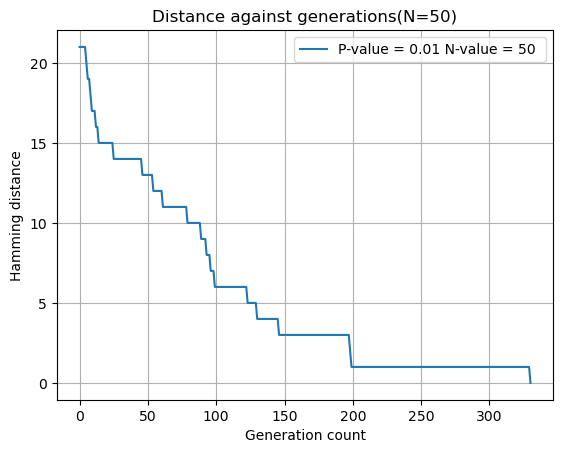

In [25]:
ham_tracking(mas_seqx[:24],0.01,50)

These graphs show that the hamming distance will decrease over generations, implying that the function converges towards the orginal string. The steepness of the curve suggests that the inital children improve more rapidly than the children later. However the flat parts of the graph show when the next generation is unable to improve so the parent is kept for the next generation.

# runs ham_offspring N times and calcuate the mean,median and S.D from that

In [39]:
def offspr_average(org,p,n,cals):
    gens = []
    for i in range(cals):
        gens.append(ham_offspring(org,p,n))
    average = sum(gens) / cals     
    return average

In [41]:
def offspr_stat(org,p,n,cals):
    gens = []
    for i in range(cals):
        gens.append(ham_offspring(org,p,n))
    SD = np.std(gens) # finds standard dev
    median = np.median(gens) #finds median
    
    return median,SD

# creates a range of generation value for P amounts (p_count) with a gap of (p_dis) for each N (N_count) with a gap of (N_dis) 

In [44]:
def offspr_range(org,p_count:int,p_dis,N_count:int,N_dis):
    p_values = [p * p_dis for p in range(1, p_count+1)]
    n_values = [n * N_dis for n in range(1, N_count+1)]
    G_values = np.zeros((p_count,N_count))
    for i in range(p_count):
        for j in range(N_count):
            x = p_values[i]
            y = n_values[j]
            G_values[i,j] = offspr_average(org,x,y,5)
            print(f"Calculated generations with p = {x}" + f" for n = {y} ") #Debug and progress track
    return p_values,n_values, G_values

In [32]:
#offspr_range(mas_seqx,2,0.005,2,100)

Calculated generations with p = 0.005 for n = 100 
Calculated generations with p = 0.005 for n = 200 
Calculated generations with p = 0.01 for n = 100 
Calculated generations with p = 0.01 for n = 200 


([0.005, 0.01],
 [100, 200],
 array([[354.8, 175.2],
        [217. , 117. ]]))

# Using these we can plot a graph that visualises the growth of generation as N and P vary

In [54]:
def ham_graph_p(org,p_count:int,p_dis,N_count:int,N_dis):
    plt.figure(figsize=(10, 6))
    p_values, n_values , G_values = offspr_range(org, p_count, p_dis,N_count, N_dis)
    for i in range(N_count):
        plt.semilogy(p_values, G_values[:,i], label=f"N-value = {n_values[i]}") # function for printing each N-val
    plt.legend()
    # plotting and labels
    plt.title("Generations against Alteration P")
    plt.xlabel("Alteration probability (p)")
    plt.ylabel("Generations untill success")
    plt.grid(True)
    plt.show()   



Calculated generations with p = 0.01 for n = 10 
Calculated generations with p = 0.01 for n = 20 
Calculated generations with p = 0.01 for n = 30 
Calculated generations with p = 0.01 for n = 40 
Calculated generations with p = 0.01 for n = 50 
Calculated generations with p = 0.02 for n = 10 
Calculated generations with p = 0.02 for n = 20 
Calculated generations with p = 0.02 for n = 30 
Calculated generations with p = 0.02 for n = 40 
Calculated generations with p = 0.02 for n = 50 
Calculated generations with p = 0.03 for n = 10 
Calculated generations with p = 0.03 for n = 20 
Calculated generations with p = 0.03 for n = 30 
Calculated generations with p = 0.03 for n = 40 
Calculated generations with p = 0.03 for n = 50 
Calculated generations with p = 0.04 for n = 10 
Calculated generations with p = 0.04 for n = 20 
Calculated generations with p = 0.04 for n = 30 
Calculated generations with p = 0.04 for n = 40 
Calculated generations with p = 0.04 for n = 50 
Calculated generatio

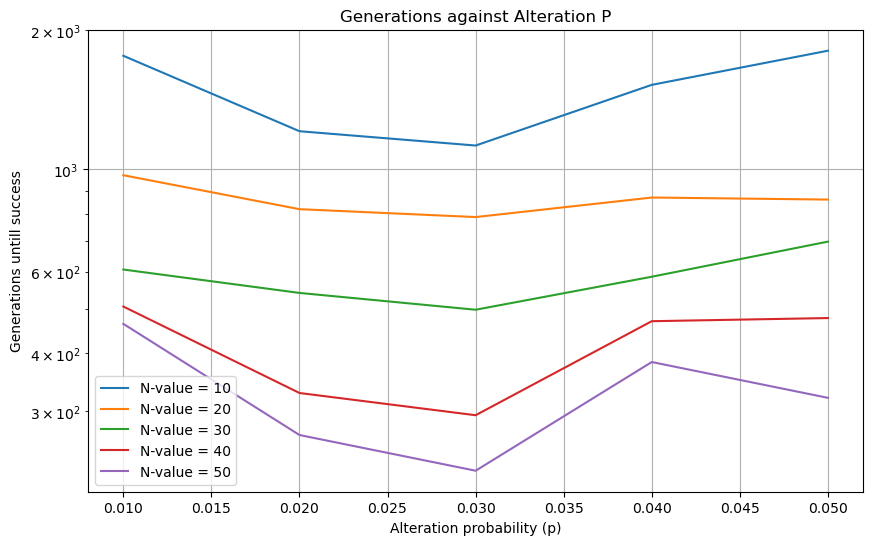

In [58]:
ham_graph_p(mas_seqx,5,0.01,5,10)

<h2>Observation: P</h2> 
This graph is in semilogy (log y vs x) because of it's wider dynamic range than a linear scale which would compress the lines together. There is an exponential relationship between p and generations, we can see this as it has a linear trend on the graph . N has a negative relationship but we can't see to what degree from this graph.

In [50]:
def ham_graph_n(org, p_count: int, p_dis, N_count: int, N_dis):
    p_values, n_values, G_values = offspr_range(org, p_count, p_dis, N_count, N_dis)    
    plt.figure(figsize=(10, 6))
    for i in range(p_count):
        plt.semilogy(n_values, G_values[i, :], label=f"p = {p_values[i]:.2f}")
    # plotting and labels
    plt.legend()
    plt.title("Generations against Population Size (N)")
    plt.xlabel("Population Size (N)")
    plt.ylabel("Generations until success (log scale)")
    plt.grid(True, which="both", linestyle='--', alpha=0.5)
    
    # Show plot
    plt.show()

Calculated generations with p = 0.01 for n = 5 
Calculated generations with p = 0.01 for n = 10 
Calculated generations with p = 0.01 for n = 15 
Calculated generations with p = 0.01 for n = 20 
Calculated generations with p = 0.01 for n = 25 
Calculated generations with p = 0.02 for n = 5 
Calculated generations with p = 0.02 for n = 10 
Calculated generations with p = 0.02 for n = 15 
Calculated generations with p = 0.02 for n = 20 
Calculated generations with p = 0.02 for n = 25 
Calculated generations with p = 0.03 for n = 5 
Calculated generations with p = 0.03 for n = 10 
Calculated generations with p = 0.03 for n = 15 
Calculated generations with p = 0.03 for n = 20 
Calculated generations with p = 0.03 for n = 25 
Calculated generations with p = 0.04 for n = 5 
Calculated generations with p = 0.04 for n = 10 
Calculated generations with p = 0.04 for n = 15 
Calculated generations with p = 0.04 for n = 20 
Calculated generations with p = 0.04 for n = 25 
Calculated generations w

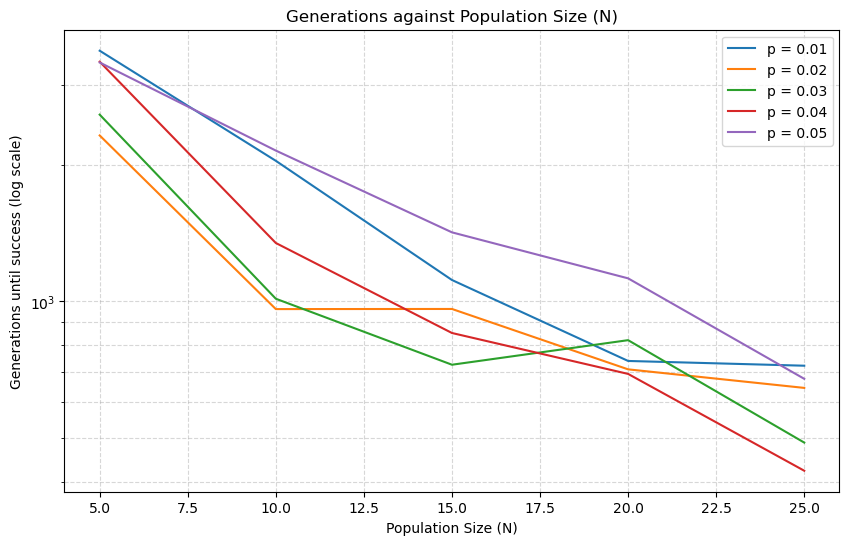

In [52]:
ham_graph_n(mas_seqx,5,0.01,5,5)

<h2>Observation: N</h2> 
Same as the last graph it's in semilogy. We can observe that N has a negative exponental relationship with generations.

In [ ]:
def ham_graph_size(org, org_count: int, org_dis: int, p , n):
    p_values, n_values, G_values = offspr_range(org, p_count, p_dis, N_count, N_dis)    
    plt.figure(figsize=(10, 6))
    for i in range(p_count):
        plt.semilogy(n_values, G_values[i, :], label=f"p = {p_values[i]:.2f}")
    # plotting and labels
    plt.legend()
    plt.title("Generations against Population Size (N)")
    plt.xlabel("Population Size (N)")
    plt.ylabel("Generations until success (log scale)")
    plt.grid(True, which="both", linestyle='--', alpha=0.5)
    
    # Show plot
    plt.show()

In [50]:
def ham_graph_size(org, org_count: int, org_size: int, p, n):
    """
    Plots generations against master sequence size for fixed p and n
    
    Parameters:
        org (str): Base master sequence pattern
        org_count (int): Number of different sizes to test
        org_size (int): Size increment between tests
        p (float): Fixed mutation probability
        n (int): Fixed population size
    """
    # Generate sequence sizes to test
    sizes = [len(org) + (i * org_size) for i in range(org_count)]
    generations = []
    
    plt.figure(figsize=(10, 6))
    
    # Test each sequence size
    for size in sizes:
        # Create sequence of current size
        current_org = (org * (size // len(org) + 1))[:size]
        
        # Get generations needed
        y = ham_offspring_tracker(current_org, p, n)
        generations.append(len(y))
    
    # Plot results
    plt.plot(sizes, generations, 'o-', linewidth=2, markersize=8)
    
    # Format plot
    plt.title(f"Generations vs Sequence Size (p={p}, N={n})")
    plt.xlabel("Master Sequence Length")
    plt.ylabel("Generations until success (log scale)")
    plt.grid(True, which="both", linestyle='--', alpha=0.5)
    
    plt.show()

In [68]:
def ham_graph_size(org, org_count: int, org_dis: int, p, n):
    """
    Plot generations against organism length (org) for given parameters.
    
    Parameters:
    - org: initial organism sequence (str)
    - org_count: number of different organism lengths to test (int)
    - org_dis: increment between organism lengths (int)
    - p: probability parameter (float)
    - n: population size parameter (int)
    """
    # Generate organism length values by taking increasingly longer prefixes
    org_values = [org[:len(org) + i*org_dis] for i in range(org_count)]
    G_values = np.zeros(org_count)
    
    # Calculate generations for each organism length
    for i in range(org_count):
        current_org = org_values[i]
        G_values[i] = offspr_range(current_org, p, n, 5)  # Using 5 trials for average
        print("Calculated for length {}: p = {}, N = {} → {} gens".format(
            len(current_org), p, n, G_values[i]))
    
    # Plotting
    plt.figure(figsize=(10, 6))
    plt.semilogy([len(o) for o in org_values], G_values, 
                label="p = {}, N = {}".format(p, n))
    
    # Plot labels and formatting
    plt.legend()
    plt.title("Generations vs Organism Length")
    plt.xlabel("Organism Length (bp)")
    plt.ylabel("Generations until success (log scale)")
    plt.grid(True, which="both", linestyle='--', alpha=0.5)
    
    plt.show()

In [70]:
ham_graph_size(mas_seq, 40, 2, 0.01, 50)

TypeError: offspr_range() missing 1 required positional argument: 'N_dis'

<h2>Observation: P</h2> 

# Using these we can also plot a Heatmap that visualises the significance of N and P to generation 

In [43]:
def ham_heat(org,p_count:int,p_dis,N_count:int,N_dis):
    p_values, n_values , G_values = offspr_range(org, p_count, p_dis,N_count, N_dis)
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        G_values,
        annot=True,  # displays value in each cell
        fmt=".1f",  # displays as real number to 1d.p
        cmap="coolwarm",  # color map 
        xticklabels=n_values,  # Label x-axis with N values
        yticklabels=p_values   # Label y-axis with p values
        )
    plt.xlabel("Population Size (N)")
    plt.ylabel("Mutation Probability (p)")
    plt.title("Heatmap of Generations (G) to Reach Master Sequence")
    plt.show()

Calculated generations with p = 0.01 for n = 10 
Calculated generations with p = 0.01 for n = 20 
Calculated generations with p = 0.01 for n = 30 
Calculated generations with p = 0.01 for n = 40 
Calculated generations with p = 0.01 for n = 50 
Calculated generations with p = 0.02 for n = 10 
Calculated generations with p = 0.02 for n = 20 
Calculated generations with p = 0.02 for n = 30 
Calculated generations with p = 0.02 for n = 40 
Calculated generations with p = 0.02 for n = 50 
Calculated generations with p = 0.03 for n = 10 
Calculated generations with p = 0.03 for n = 20 
Calculated generations with p = 0.03 for n = 30 
Calculated generations with p = 0.03 for n = 40 
Calculated generations with p = 0.03 for n = 50 
Calculated generations with p = 0.04 for n = 10 
Calculated generations with p = 0.04 for n = 20 
Calculated generations with p = 0.04 for n = 30 
Calculated generations with p = 0.04 for n = 40 
Calculated generations with p = 0.04 for n = 50 
Calculated generatio

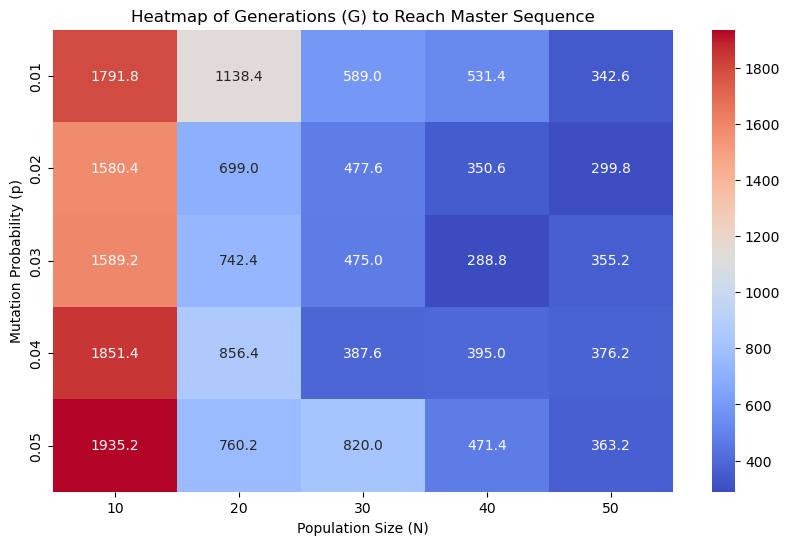

In [44]:
ham_heat(mas_seqx,5,0.01,5,10)

A big problem that you may have seen is that because generation ^ 2 is shown to be exponentaly proportional to p it's difficult to visualise for large p and small n 

In [46]:
#convergence_rae(mas_seqx,0.4,50)

However using this method, we still are limited by large p as the k constant reaches overflow errors as it's that small. So I decided to use a simplier method that just finds the average linear convergence rate 

In [48]:
def linear_converge_rate(org,p,n,estimate = False ):
    y= ham_offspring_tracker(org, p, n)
    x = len(y)
    converge = ((max(y) + min(y)) ) / (x * y[0]) # added y[0] in order to standardise the data as the inital generation is a random ham distance
    if estimate == False:
        return converge * 1000000
    elif estimate == True:
        guess = 1 / converge
        print(f"Estimated {guess} for p = {p} with n = {n} ")
        return guess

In [49]:
linear_converge_rate(mas_seqx,1,10)
linear_converge_rate(mas_seqx,1,10,estimate = True)

Timeout reached. Returning results collected so far.
Timeout reached. Returning results collected so far.
Estimated 17198.035714285714 for p = 1 with n = 10 


17198.035714285714

In [50]:
def conv_rate_range(org,p_count:int,p_dis,N_count:int,N_dis):
    p_values = [p * p_dis for p in range(1, p_count+1)]
    n_values = [n * N_dis for n in range(1, N_count+1)]
    R_values = np.zeros((p_count,N_count))
    for i in range(p_count):
        for j in range(N_count):
            x = p_values[i]
            y = n_values[j]
            R_values[i,j] = linear_converge_rate(org,x,y)
            print(f"Calculated rate with p = {x}" + f" for n = {y} ") #Debug and progress track
    return p_values,n_values, R_values

In [51]:
#conv_rate_range(mas_seqx,2,0.005,2,100)

In [52]:
def conv_rate_heat(org,p_count:int,p_dis,N_count:int,N_dis):
    p_values, n_values , R_values = conv_rate_range(org, p_count, p_dis,N_count, N_dis)
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        R_values,
        annot=True,  # displays value in each cell
        fmt=".1f",  # displays as real number to 1d.p
        cmap="coolwarm_r",  # color map, reverse because high value = better
        xticklabels=n_values,  # Label x-axis with N values
        yticklabels=p_values   # Label y-axis with p values
        )
    plt.xlabel("Population Size (N)")
    plt.ylabel("Mutation Probability (p)")
    plt.title("Heatmap of Convergence Rate * 10^6")
    plt.show()

Calculated rate with p = 0.1 for n = 500 
Calculated rate with p = 0.1 for n = 1000 
Calculated rate with p = 0.1 for n = 1500 
Calculated rate with p = 0.1 for n = 2000 
Calculated rate with p = 0.1 for n = 2500 
Timeout reached. Returning results collected so far.
Calculated rate with p = 0.2 for n = 500 
Timeout reached. Returning results collected so far.
Calculated rate with p = 0.2 for n = 1000 
Timeout reached. Returning results collected so far.
Calculated rate with p = 0.2 for n = 1500 
Timeout reached. Returning results collected so far.
Calculated rate with p = 0.2 for n = 2000 
Timeout reached. Returning results collected so far.
Calculated rate with p = 0.2 for n = 2500 
Timeout reached. Returning results collected so far.
Calculated rate with p = 0.30000000000000004 for n = 500 
Timeout reached. Returning results collected so far.
Calculated rate with p = 0.30000000000000004 for n = 1000 
Timeout reached. Returning results collected so far.
Calculated rate with p = 0.3000

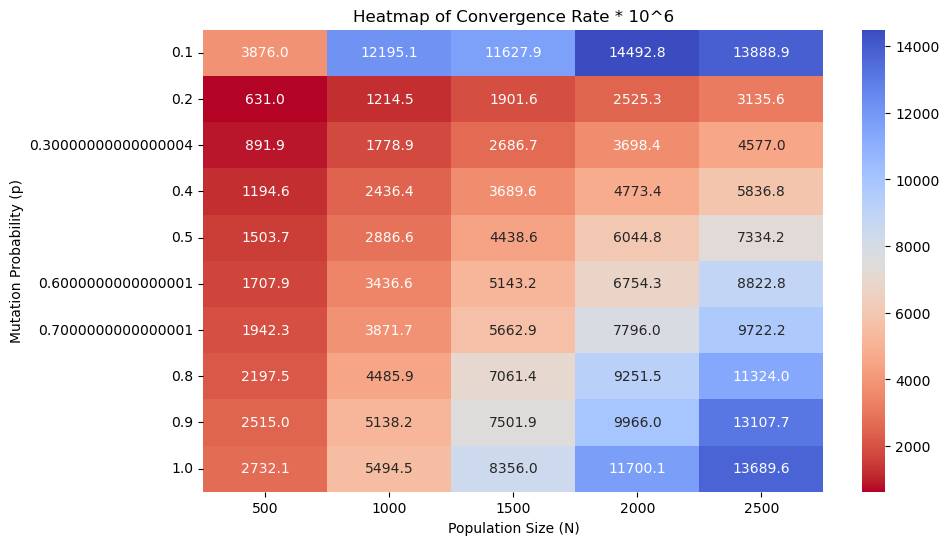

In [53]:
conv_rate_heat(mas_seqx,10,0.1,5,500)

This will allow us to better see how values of p and n (for all values now) effect the rate that we reach the generation with hamming distance 0. We can also use this to approximate the amount of generation would be needed for the higher values 